In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
HIST_PATH = Path("Results/train_history")
# N_LAYERS = [3, 5, 7, 9, 11, 13, 15, 17, 20]
N_LAYERS = [3, 11, 20]

### Complete training

In [3]:
losses = {}
for layer in N_LAYERS:
    df = pd.read_csv(HIST_PATH / f"{layer}layers/train_history_{layer}layers.csv")
    train_loss = df["train_loss"].to_numpy()
    val_loss = df["val_loss"].to_numpy()
    local_dict = {"train": train_loss, "val": val_loss}
    losses[f"{layer}layers"] = local_dict    

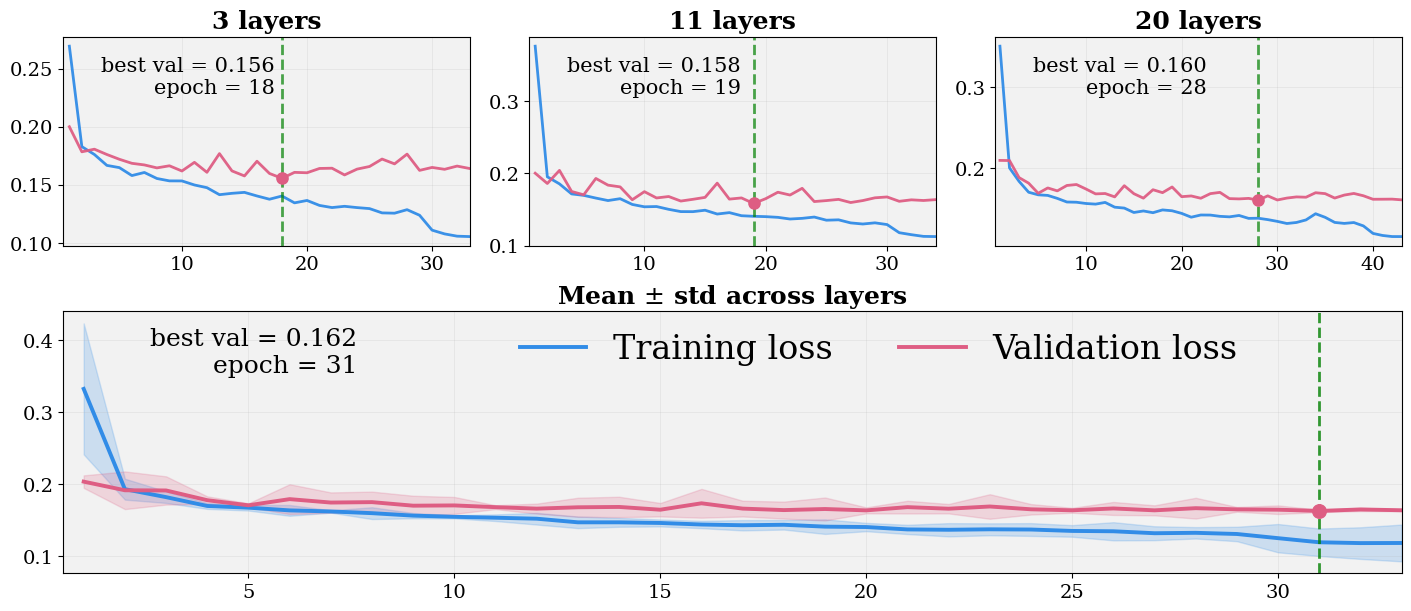

In [34]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "serif"
train_color = "#318CE7"
val_color = "#DE5D83"

# ------------------------------------------------------------
# Compute mean/std curves
# ------------------------------------------------------------
train_curves = []
val_curves = []

min_len = min(len(ldict["train"]) for ldict in losses.values())

for ldict in losses.values():
    train_curves.append(ldict["train"][:min_len])
    val_curves.append(ldict["val"][:min_len])

train_curves = np.asarray(train_curves)
val_curves = np.asarray(val_curves)

epochs = np.arange(1, min_len + 1)

train_mean = train_curves.mean(axis=0)
train_std = train_curves.std(axis=0)

val_mean = val_curves.mean(axis=0)
val_std = val_curves.std(axis=0)

best_epoch_mean = np.argmin(val_mean) + 1
best_val_mean = np.min(val_mean)

fig = plt.figure(figsize=(14, 6), constrained_layout=True)

gs = fig.add_gridspec(nrows=2, ncols=3, height_ratios=[1, 1.25])

individual_axes = [fig.add_subplot(gs[0, c]) for c in range(3)]

ax0 = fig.add_subplot(gs[1, :])

# # ------------------------------------------------------------
# # Layout: top mean plot + 3x3 individual folds
# # ------------------------------------------------------------
# fig = plt.figure(figsize=(14, 6), constrained_layout=True)

# gs = fig.add_gridspec(nrows=2, ncols=3, height_ratios=[1.25, 1])

# ax0 = fig.add_subplot(gs[0, :])

# individual_axes = []
# for r in range(1, 2):
#     for c in range(3):
#         individual_axes.append(fig.add_subplot(gs[r, c]))

# ============================================================
# TOP PANEL: Mean ± std
# ============================================================
ax0.plot(epochs, train_mean, linewidth=2.8, color=train_color, label="Training loss")
ax0.fill_between(epochs, train_mean - 2 * train_std, train_mean + 2 * train_std, 
                 color=train_color, alpha=0.20)

ax0.plot(epochs, val_mean, linewidth=2.8, color=val_color, label="Validation loss")
ax0.fill_between(epochs, val_mean - 2 * val_std, val_mean + 2 * val_std, 
                 color=val_color, alpha=0.20)

ax0.axvline(best_epoch_mean, linestyle="--", linewidth=2, alpha=0.8, color="green")
ax0.scatter(best_epoch_mean, best_val_mean, s=95, zorder=5, color=val_color)

ax0.set_title(r"Mean $\pm$ std across layers", fontweight="bold", fontsize=18)
ax0.tick_params(axis='both', labelsize=14)
ax0.set_facecolor("#f2f2f2")
ax0.grid(True, linewidth=0.4, alpha=0.3)

ax0.text(0.22, 0.75, 
         f"best val = {best_val_mean:.3f}\nepoch = {best_epoch_mean}", 
         transform=ax0.transAxes, ha="right", va="bottom", fontsize=18)

ax0.set_xlim([0.5, len(epochs)])

handles, labels = ax0.get_legend_handles_labels()

ax0.legend(handles, labels, loc="upper right", 
           ncol=2, fontsize=24, frameon=False, bbox_to_anchor=(0.9, 1.03))

# ============================================================
# BOTTOM PANELS: Individual folds, 3x3
# ============================================================
for i, (fold_name, ldict) in enumerate(losses.items()):

    ax = individual_axes[i]

    train = np.asarray(ldict["train"])
    val = np.asarray(ldict["val"])

    n_epochs = len(train)
    e = np.arange(1, n_epochs + 1)
        
    best_epoch = np.argmin(val) + 1
    best_val = np.min(val)

    ax.plot(e, train, linewidth=2.0, alpha=0.95, color=train_color)
    ax.plot(e, val, linewidth=2.0, alpha=0.95, color=val_color)

    ax.axvline(best_epoch, linestyle="--", linewidth=2, alpha=0.7, color="green")
    ax.scatter(best_epoch, best_val, s=65, zorder=5, color=val_color)

    ax.set_xlim([0.5, n_epochs])
    ax.set_title(f"{N_LAYERS[i]} layers", fontsize=18, fontweight="bold")
    ax.set_facecolor("#f2f2f2")

    ax.text(0.52, 0.71, 
            f"best val = {best_val:.3f}\nepoch = {best_epoch}", 
            transform=ax.transAxes, ha="right", va="bottom", fontsize=15)

    ax.grid(True, linewidth=0.4, alpha=0.3)
    ax.tick_params(axis='both', labelsize=14)

# ------------------------------------------------------------
# Save
# ------------------------------------------------------------
plt.savefig("Results/losses_combined.pdf", bbox_inches="tight")
plt.show()

### Retraining 11 layers